# Exploración de Incidentes — PISST
**Objetivo:** Explorar los datos de incidentes para validar la lógica que irá a `analytics_service.py`

Este notebook es de solo lectura — nunca escribe en la BD.

## 1. Configuración e imports

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

sys.path.insert(0, os.path.abspath('..'))
load_dotenv('../.env')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print('Pandas:', pd.__version__, '| NumPy:', np.__version__)

Pandas: 3.0.3 | NumPy: 2.4.6


## 2. Conexión a la BD

In [2]:
DATABASE_URL = os.getenv("DATABASE_URL")

# Filtrar por empresa — cambiar este UUID según la empresa a analizar
EMPRESA_ID = os.getenv("EMPRESA_ID", None)  # None = leer todas (solo para desarrollo)

print("Conectando a:", DATABASE_URL[:40], "...")
if EMPRESA_ID:
    print("Filtrando por empresa:", EMPRESA_ID)
else:
    print("[ADVERTENCIA] Sin filtro de empresa — se muestran datos de TODOS los clientes")

engine = create_engine(DATABASE_URL)

# Verificar conexión
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM incidentes"))
    total = result.scalar()
    print(f"Total incidentes en BD: {total}")


Conectando a: postgresql://neondb_owner:npg_rN18PdwOtz ...
[ADVERTENCIA] Sin filtro de empresa — se muestran datos de TODOS los clientes
Total incidentes en BD: 13


## 3. Carga de datos (Ingesta)

In [3]:
filtro_empresa = f"WHERE i.empresa_id = '{EMPRESA_ID}'" if EMPRESA_ID else ""

query = f"""
SELECT
    i.id,
    i.tipo,
    i.severidad,
    i.estado,
    i.fecha,
    i.empresa_id,
    a.nombre AS area_nombre
FROM incidentes i
LEFT JOIN users u  ON u.id = i.trabajador_afectado_id
LEFT JOIN areas a  ON a.id = u.area_id
{filtro_empresa}
"""

df = pd.read_sql(query, engine)
print(f"Registros cargados: {len(df)}")
df.head()


Registros cargados: 13


,id,tipo,severidad,estado,fecha,empresa_id,area_nombre
0,c303b4fd-c6e9-405e-9519-dd7017f557f3,accidente,leve,en_revision,2026-06-10 21:23:00,eae57674-a3fd-420f-b3c4-0800d98a0f93,None
1,4a82e858-fa49-4ddf-b306-2ad0d5ddcc2e,incidente,leve,borrador,2026-06-10 21:19:00,eae57674-a3fd-420f-b3c4-0800d98a0f93,None
2,863bc1b2-c3bd-43b5-8e7e-be7919ae3c7e,accidente,leve,borrador,2026-06-10 21:18:00,eae57674-a3fd-420f-b3c4-0800d98a0f93,None
3,b8855639-b8f8-4bcd-a02e-7a4d98e2600a,cuasi_accidente,leve,en_revision,2026-06-10 09:04:00,eae57674-a3fd-420f-b3c4-0800d98a0f93,None
4,074a5643-dda0-43b6-8737-7511043291dc,cuasi_accidente,leve,en_revision,2026-06-10 11:33:00,eae57674-a3fd-420f-b3c4-0800d98a0f93,None


## 4. Inspección estructural

In [4]:
print('Shape:', df.shape)
print()
df.info()

Shape: (13, 7)

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           13 non-null     object        
 1   tipo         13 non-null     str           
 2   severidad    13 non-null     str           
 3   estado       13 non-null     str           
 4   fecha        13 non-null     datetime64[us]
 5   empresa_id   13 non-null     object        
 6   area_nombre  0 non-null      object        
dtypes: datetime64[us](1), object(3), str(3)
memory usage: 860.0+ bytes


In [5]:
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
id              0
tipo            0
severidad       0
estado          0
fecha           0
empresa_id      0
area_nombre    13
dtype: int64


## 5. Análisis descriptivo

In [6]:
print('Distribución por tipo:')
print(df['tipo'].value_counts())
print()
print('Distribución por severidad:')
print(df['severidad'].value_counts())
print()
print('Distribución por estado:')
print(df['estado'].value_counts())

Distribución por tipo:
tipo
accidente             7
condicion_insegura    3
cuasi_accidente       2
incidente             1
Name: count, dtype: int64

Distribución por severidad:
severidad
leve        6
moderada    6
grave       1
Name: count, dtype: int64

Distribución por estado:
estado
en_investigacion    6
en_revision         3
borrador            3
cerrado             1
Name: count, dtype: int64


## 5b. Visualizaciones

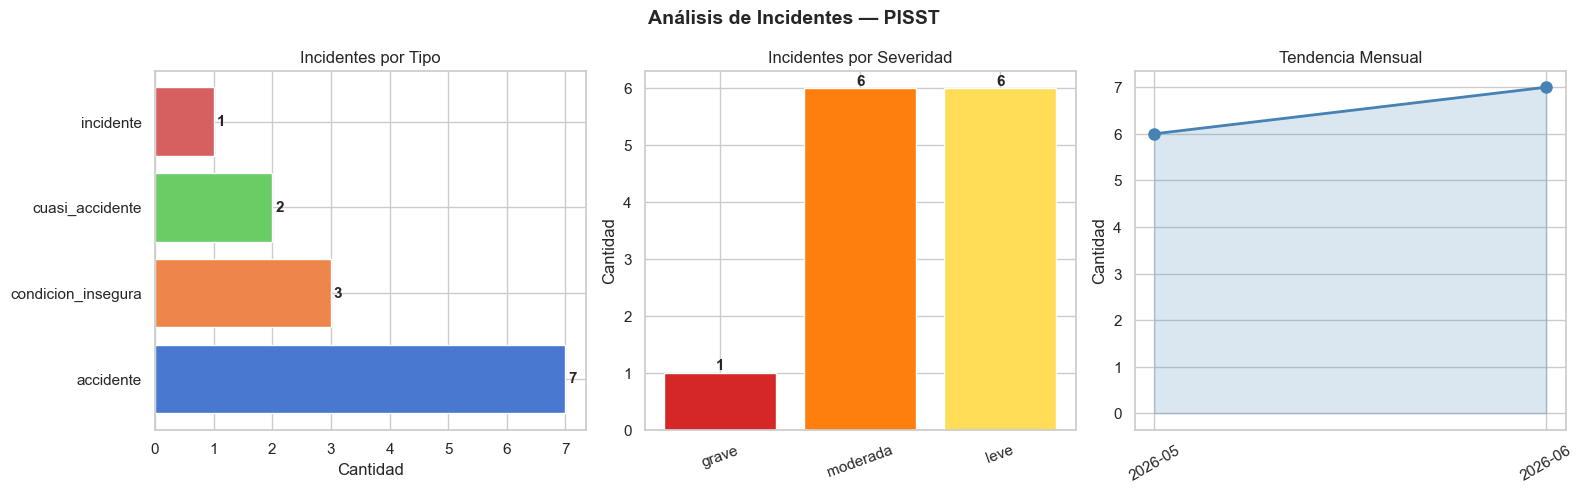

Gráfica guardada en data/processed/incidentes_graficas.png


In [7]:
if len(df) > 0:
    df['fecha'] = pd.to_datetime(df['fecha'])
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Análisis de Incidentes — PISST', fontsize=14, fontweight='bold')

    # --- Gráfica 1: Distribución por tipo ---
    tipo_counts = df['tipo'].value_counts()
    axes[0].barh(tipo_counts.index, tipo_counts.values, color=sns.color_palette("muted", len(tipo_counts)))
    axes[0].set_title('Incidentes por Tipo')
    axes[0].set_xlabel('Cantidad')
    for i, v in enumerate(tipo_counts.values):
        axes[0].text(v + 0.05, i, str(v), va='center', fontweight='bold')

    # --- Gráfica 2: Distribución por severidad ---
    orden_severidad = ['mortal', 'grave', 'moderada', 'leve', 'sin_lesion']
    severidad_counts = df['severidad'].value_counts().reindex(
        [s for s in orden_severidad if s in df['severidad'].values], fill_value=0
    )
    colores_severidad = ['#d62728', '#ff7f0e', '#ffdd57', '#2ca02c', '#aec7e8'][:len(severidad_counts)]
    axes[1].bar(severidad_counts.index, severidad_counts.values, color=colores_severidad)
    axes[1].set_title('Incidentes por Severidad')
    axes[1].set_ylabel('Cantidad')
    axes[1].tick_params(axis='x', rotation=20)
    for i, v in enumerate(severidad_counts.values):
        axes[1].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

    # --- Gráfica 3: Tendencia mensual ---
    df['mes'] = df['fecha'].dt.to_period('M').astype(str)
    mensual = df.groupby('mes').size().reset_index(name='cantidad')
    axes[2].plot(mensual['mes'], mensual['cantidad'], marker='o', linewidth=2,
                 color='steelblue', markersize=8)
    axes[2].fill_between(mensual['mes'], mensual['cantidad'], alpha=0.2, color='steelblue')
    axes[2].set_title('Tendencia Mensual')
    axes[2].set_ylabel('Cantidad')
    axes[2].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    os.makedirs('../data/processed', exist_ok=True)
    plt.savefig('../data/processed/incidentes_graficas.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfica guardada en data/processed/incidentes_graficas.png')
else:
    print('Sin datos para graficar.')

## 6. Transformaciones y cálculos (lógica del servicio)

In [8]:
if len(df) == 0:
    print('Sin datos — el servicio retornaría ceros.')
else:
    df['fecha'] = pd.to_datetime(df['fecha'])

    # Distribuciones
    por_tipo = df['tipo'].value_counts().to_dict()
    por_severidad = df['severidad'].value_counts().to_dict()

    # Tasa mensual promedio
    meses_activos = df['fecha'].dt.to_period('M').nunique()
    tasa_mensual = round(len(df) / max(meses_activos, 1), 1)

    # Top 3 áreas
    top_areas = df['area_nombre'].dropna().value_counts().head(3).index.tolist()

    # Tendencia — comparar último mes vs mes anterior
    df_sorted = df.sort_values('fecha')
    ultimo_mes = df_sorted['fecha'].max().to_period('M')
    mes_anterior = (ultimo_mes - 1)
    ultimo = len(df[df['fecha'].dt.to_period('M') == ultimo_mes])
    anterior = len(df[df['fecha'].dt.to_period('M') == mes_anterior])
    tendencia = 'estable' if anterior == 0 else ('aumento' if ultimo > anterior * 1.2 else ('baja' if ultimo < anterior * 0.8 else 'estable'))

    resultado = {
        'total_incidentes': len(df),
        'por_tipo': por_tipo,
        'por_severidad': por_severidad,
        'tasa_mensual_promedio': tasa_mensual,
        'top_areas': top_areas,
        'tendencia': tendencia,
    }

    import json
    print(json.dumps(resultado, indent=2, ensure_ascii=False))

{
  "total_incidentes": 13,
  "por_tipo": {
    "accidente": 7,
    "condicion_insegura": 3,
    "cuasi_accidente": 2,
    "incidente": 1
  },
  "por_severidad": {
    "leve": 6,
    "moderada": 6,
    "grave": 1
  },
  "tasa_mensual_promedio": 6.5,
  "top_areas": [],
  "tendencia": "estable"
}


## 7. Exportación de hallazgos

In [9]:
import os
os.makedirs('../data/processed', exist_ok=True)

if len(df) > 0:
    df.to_csv('../data/processed/incidentes_explorados.csv', index=False)
    print('Exportado a data/processed/incidentes_explorados.csv')

Exportado a data/processed/incidentes_explorados.csv


## 8. Conclusiones para el servicio

- La función `analizar_incidentes()` puede usar `value_counts()` directamente sobre el DataFrame
- La tasa mensual se calcula dividiendo `len(df)` entre el número de meses distintos con al menos un incidente
- La tendencia compara el último mes calendar vs el anterior (umbral ±20%)
- Si no hay datos, el servicio retorna ceros sin levantar excepción